In [134]:
#K Nearest Neighbor Classifier Project for Week 2 Critical Thinking Option 1 Iris Data
#John Wensink
#CSC525 Principles of Machine Learning
#Colorado State University - Global Campus
#Dr. Dong Nguyen
#May 25, 2025

In [144]:
#Cell 1 for data loading, inspection, feature/label separation
#(Pandas Development Team, 2024)
import pandas as pd

#Import the Iris csv data into a 2D DataFrame
df = pd.read_csv("data/w2ct_iris.csv")

#Display the number of samples for each Iris species in the dataset
df["Name"].value_counts()
print(df["Name"].value_counts())

#Use head() to display the first 5 rows to verify structure and contents
print("\nDataset Preview:")
print(df.head())

#Use isnull() to mark a missing value as boolean True (1), use sum() to count how many
print("\nMissing values per column:")
print(df.isnull().sum())

#Declare the variable features and assign it the values of a column of the DataFrame
features = df[["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]]
#Declare the variable species here and assign it the value from the 'Name' column
species = df["Name"]

#Print a sample of features
print("\nFeature sample:")
print(features.head())

#Print a sample of labels
print("\nLabel sample:")
print(species.head())
#(GeeksforGeeks, 2025) (Pandas, 2024)

#Here we've loaded the csv data into a Pandas DataFrame. We then perform some checks to validate the integrity of the data, as well as start to get a feel for what our dataset is made of. We can see that the class distribution is balanced across the three species equally, which is nice. After validation, we separate the dataset into features and labels, which prepares the data for training into our ML model. The features will be the four measurements as floats and the target will be the string name of our species. This is a 'toy' dataset that is already nice and clean for use, minimal if any preprocessing will be needed, but it would probably make sense to standardize the measurements as petal lengths and sepal lengths would cause issues with the longer petal lengths dominating the distance-based calculations as they are a bit longer than the sepal lengths. We'll apply that standardization in cell 2.

Name
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Dataset Preview:
           SepalLength           SepalWidth          PetalLength  \
0               5.1000               3.5000               1.4000   
1               4.9000               3.0000               1.4000   
2               4.7000               3.2000               1.3000   
3               4.6000               3.1000               1.5000   
4               5.0000               3.6000               1.4000   

            PetalWidth         Name  
0               0.2000  Iris-setosa  
1               0.2000  Iris-setosa  
2               0.2000  Iris-setosa  
3               0.2000  Iris-setosa  
4               0.2000  Iris-setosa  

Missing values per column:
SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Name           0
dtype: int64

Feature sample:
           SepalLength           SepalWidth          PetalLength  \
0               5.1000               

In [136]:
#Cell 2 will import sklearn's StandardScalar preprocessing module and put our data into a Pandas DataFrame

#We want to normalize our z-score for this dataset so that our relatively large length measurements don't dominate our distance calculations compared to our relatively small width measurements
#We can standardize our data by rescaling absolute measurements as a function of average value and standard deviation instead, important when using k-NN which relies on Euclidian distances
#Since our dataset is purely numeric, with few outliers, and has a roughly Gaussian distribution StandardScaler is probably the best choice because we don't need outlier protection a la RobustScaler (Scikit-learn, n.d. -e)
from sklearn.preprocessing import StandardScaler as ss

#Declare the variable scaler as an instance of StandardScaler
scaler = ss()
#Declare the variable features_scaled as the standardized version of features using z-score normalization (value x - mean μ ) / standard deviation σ
features_scaled = scaler.fit_transform(features)

#Let's make a DataFrame to check our progress showing the first, middle, and last 3 samples to make sure our scaling was applied consistently across the targets
scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

#Find the middle rows of our dataset and declare it as middle_rows
middle_index = len(scaled_df) // 2
middle_rows = scaled_df.iloc[middle_index -1 : middle_index + 2]

#Make a concatenated DataFrame showing the 3 first, middle, and last rows, and display it in our Jupyter notebook
pd.concat([
    pd.DataFrame(features_scaled, columns=features.columns).head(3),
    pd.DataFrame(middle_rows),
    pd.DataFrame(features_scaled, columns=features.columns).tail(3)
])

#Cell 2 performs z-score normalization on the features to prepare it for modeling by using sklearn's StandardScaler given the nature of the dataset. The feature values are purely numeric, exhibit few outliers, and are roughly Gaussian in distribution, conditions for which StandardScaler is well suited. Without standardization, features with larger numeric ranges (petal length) would dominate the distance calculations and cause bias in the model. The cell concludees by displaying a sample of the first, middle, and last rows of the scaled dataset to verify the transformation was applied consistently.

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,-0.9007,1.0321,-1.3413,-1.3130
1,-1.1430,-0.1250,-1.3413,-1.3130
2,-1.3854,0.3378,-1.3981,-1.3130
74,0.6745,-0.3564,0.3078,0.1332
75,0.9168,-0.1250,0.3647,0.2647
76,1.1592,-0.5878,0.5922,0.2647
147,0.7957,-0.1250,0.8196,1.0535
148,0.4322,0.8007,0.9334,1.4480
149,0.0687,-0.1250,0.7628,0.7906


In [137]:
#Cell 3 we will handle our train/test split using sklearn's train_test_split (Scikit-learn, n.d. -f)
from sklearn.model_selection import train_test_split as tts

#A standard 80/20 split seems appropriate given that our data is already normalized, clean, and balanced across targets. No need to stratify or oversample/undersample like might be needed for real-world 'messy' data
features_train, features_test, species_train, species_test = tts(
    features_scaled, species, test_size=0.2
    #, random_state=13 #uncomment for reproducibility or leave commented for random train/test split
)

# Confirm that the training and testing sets have the correct shapes
print("Training features shape:", features_train.shape)
print("Testing features shape:", features_test.shape)
print("Training target shape:", species_train.shape)
print("Testing target shape:", species_test.shape)

# Show class distribution in training and test sets
print("\nClass distribution in training set:")
print(species_train.value_counts())

print("\nClass distribution in test set:")
print(species_test.value_counts())

#Cell 3 performs the train/test split using sklearn's train_test_split function. This divides the standardized data and corresponding class labels into training and testing subsets. An 80/20 split is commonly used when working with clean and balanced datasets, and I see no reason to deviate from that here. In real-world datasets, additional considerations like stratification or over/undersampling might be necessary to handle class imbalance or noise, but in this case, the data is well-behaved and evenly distributed across species. The resulting training and testing data sets are checked for shape and class distribution to make sure the split was performed correctly. This was a relatively benign preprocessing stage, as the dataset came to us clean and nearly ready for use.

Training features shape: (120, 4)
Testing features shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)

Class distribution in training set:
Name
Iris-versicolor    41
Iris-setosa        40
Iris-virginica     39
Name: count, dtype: int64

Class distribution in test set:
Name
Iris-virginica     11
Iris-setosa        10
Iris-versicolor     9
Name: count, dtype: int64


In [138]:
#Cell 4 we will introduce the k-NN classifier from sklearn, we'll import the classifier, instantiate it with n_neighbors=5, and fit it on the training data

#Even though our features are numerical, our target is still categorical and as such a classifier is appropriate here instead of a regressor
from sklearn.neighbors import KNeighborsClassifier as knn #(Scikit-learn, n.d. -d)

#Instantiate and fit the k-NN model
model = knn(n_neighbors=5) #All other hyperparameters use default values (metric=minkowski, p=2, weights=uniform, algorithm='auto')
model.fit(features_train, species_train)

#Display the model's hyperparameters
print("k-NN Configuration:")
print(model.get_params())

#In Cell 4, we imported the k-nearest neighbors (k-NN) classifier from sklearn. Most of the model's hyperparameters were left at their default settings, but we explicitly set k=5 to define the number of nearest neighbors considered when predicting the class of a new, unseen sample. By default, the model uses the Minkowski distance metric with p=2, which is functionally equivalent to Euclidian distance. This is a common and effective choice, although other metrics like Manhattan distance (p=1) or even custom-defined metrics could be used depending on the nature of the feature space or the problem that needs to be solved. The model was trained using the standardized training data, and its configuration was printed to confirm the hyperparameter settings.

k-NN Configuration:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [139]:
#Cell 5 we will evaluate the trained k-NN model using the testing data. We'll use the test features to make predictions and compare them to the species labels

#Sklearn's accuracy_score is used to evaluate the model, it measures how often the model's predictions match the data's true label. Accuracy = correct predictions / total predictions. Since our data is balanced accuracy is appropriate, if it were imbalanced I might consider some combination of precision, recall, or F1 for a more useful measurement
from sklearn.metrics import accuracy_score #(Scikit-learn, n.d. -a)

#Just for fun let's also run a classification_report to measure precision, recall, F1, and support. I expect that it will be very close to accuracy due to our 'toy' dataset
from sklearn.metrics import classification_report #Scikit-learn, n.d.)

#Make predictions on the test features
kNN_guess = model.predict(features_test)

#Evaluate the model's prediction accuracy
accuracy = accuracy_score(species_test, kNN_guess)

#Print the results for accuracy
print(f"Model accuracy on test data: {accuracy: .3f}")

#Print the classification report results
print("\nClassification report:")
print(classification_report(species_test, kNN_guess))

#Cell 5 evaluates the performance of the trained k-NN model using the split testing data. The model generates predictions for the test set, which are then compared to the true species label using sklearn's accuracy_score function. This calculates the proportion of correct predictions out of the total number of predictions. Because the Irris dataset is clean and balanced, accuracy is a suitable evaluation metric. For additional insight and to simulate evaluation practices in real-world data, the cell also prints a sklearn classification_report, which includes precision, recal, F1, and support scores foe each class. In this particular case, we expect the classification metrics to closely mirror the accuracy score due to the simplicity and balance of the dataset. This cell provides a quick performance summary and a more detailed breakdown of how the model performs across individual classes.

Model accuracy on test data:  1.000

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



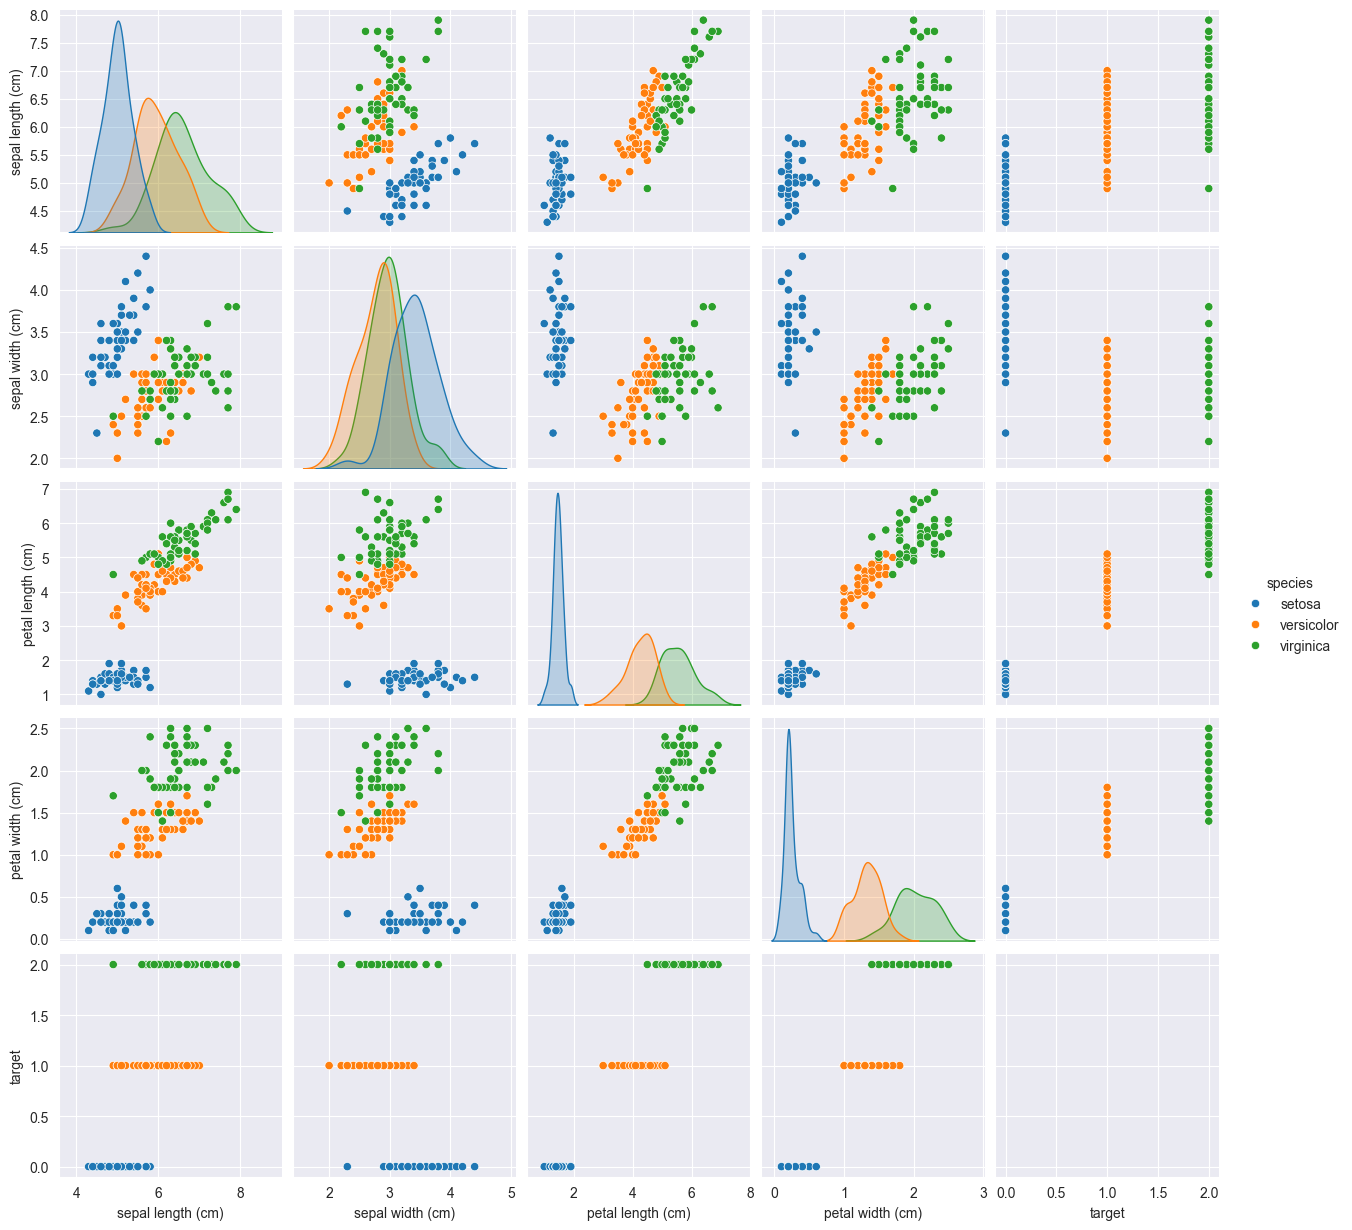

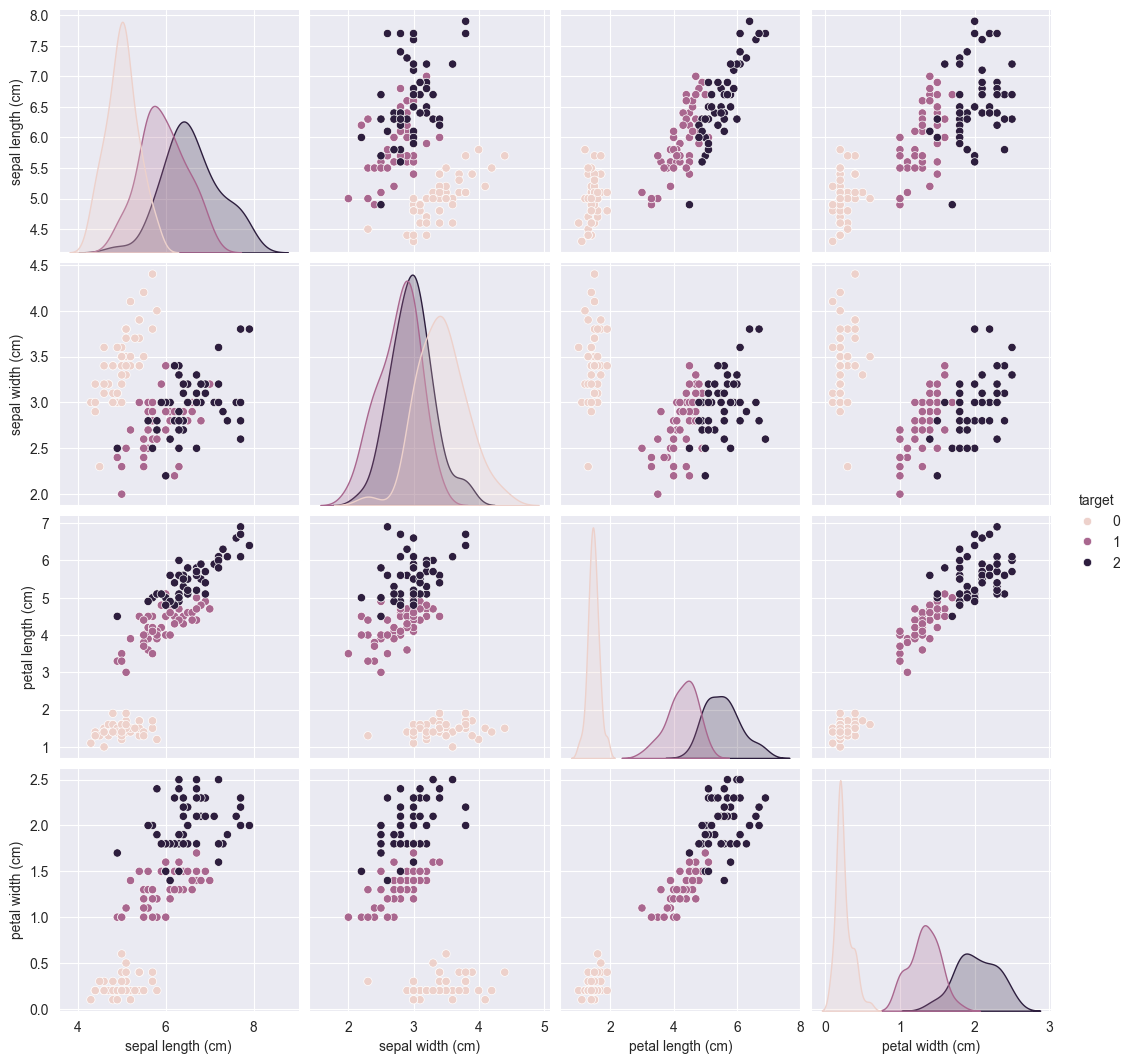

In [140]:
#Cell 6 Import our textbooks visualization of the iris data from chapter 3 (Fenner, 2020, p 58)
import importlib
import IrisData_Visualization as plots
_ = importlib.reload(plots) #Reloads the library _ = prevents displaying the path

#These two pair plots from the iris dataset visualize how the features relate to one another and how well they separate the different iris species.

#The top plot shows how sepal and petal dimensions vary by species name, using color-coded classes. We can see that Setosa (blue) is clearly separable as it occupies its own distinct cluster for petal length and width. Versicolor (orange) and Virginica (green) overlap somewhat, with Virginica tendint to have longer and wider petals than Versicolor, without much difference in sepal length.

#The bottom plot is essentially the same data, but colored by target integer instead of species name. 0 = Setosa, 1 = Versicolor, and 2 = Virginica

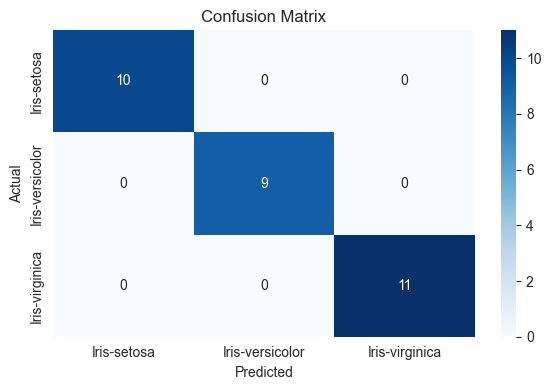


Raw Confusion Matrix:
                      Iris-setosa  Iris-versicolor   Iris-virginica
    Iris-setosa               10                0                0
Iris-versicolor                0                9                0
 Iris-virginica                0                0               11


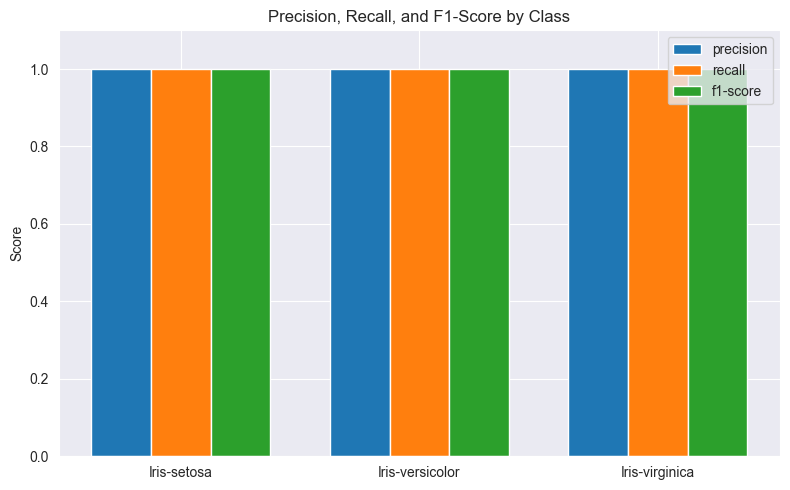

Scores used for plotting:

Precision:
  Iris-setosa: 1.00
  Iris-versicolor: 1.00
  Iris-virginica: 1.00

Recall:
  Iris-setosa: 1.00
  Iris-versicolor: 1.00
  Iris-virginica: 1.00

F1-score:
  Iris-setosa: 1.00
  Iris-versicolor: 1.00
  Iris-virginica: 1.00



In [141]:
# Cell 7: Visualize k-NN classification performance using a confusion matrix and bar plots of key metrics. I used an LLM (Grimoire, 2025) to help with some of the visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Generate the confusion matrix to compare predicted vs. actual labels
cm = confusion_matrix(species_test, kNN_guess, labels=model.classes_)

# Plot the confusion matrix as a heatmap (Scikit-learn, n.d. -c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#Print raw confusion matrix with labeled columns.
print("\nRaw Confusion Matrix:")
header = " " * 18 + "  ".join(f"{label:>15s}" for label in model.classes_)
print(header)
for actual_label, row in zip(model.classes_, cm):
    row_str = "  ".join(f"{val:>15d}" for val in row)
    print(f"{actual_label:>15s}  {row_str}")


#Extract precision, recall, and F1-score for each class from the classification report (Scikit-learn, n.d. -b)
report = classification_report(species_test, kNN_guess, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
classes = model.classes_

#Organize scores for each metric and class into a dictionary
scores = {metric: [report[label][metric] for label in classes] for metric in metrics}

#Prepare to plot grouped bar charts
x = range(len(classes))
width = 0.25

#Bar chart construction using MatPlotLib
plt.figure(figsize=(8, 5))
for i, metric in enumerate(metrics):
    plt.bar([p + width * i for p in x], scores[metric], width=width, label=metric)

# Configure axis labels and layout
plt.xticks([p + width for p in x], classes)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-Score by Class")
plt.legend()
plt.tight_layout()
plt.show()

#Output the text scores used to make the plot
print("Scores used for plotting:\n")
for metric in metrics:
    print(f"{metric.capitalize()}:")
    for cls, score in zip(classes, scores[metric]):
        print(f"  {cls}: {score:.2f}")
    print()  # Blank line for readability


#Given the separation of the classes in these pair plots, we should expect the classifier to perform quite well. In both pair plots Setosa is completely isolated from the other two classes in feature space, and k-NN should be able to easily classify Setosa with near perfect accuracy, as its features do not overlap with those of Versicolor or Virginica. We might expect some confusion between Versicolor and Virginica, due to the overlap in sepal width vs sepal length. Expecting accuracy in the 90%s overall, precision/recall should be near 100% for Setosa and maybe a bit lower for Versiccolor and Virginica, and F1 will likely be highest for Setosa and a bot lower for the other two. Let's see what happens!


In [142]:
#Cell 8 User Inpuut Prediction

#Define the predict_iris_species function with 4 parameters for the DataFrame
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width):
    #Create a new DataFrame called user_input
    user_input = pd.DataFrame(
    #Pandas needs data in a 2D format, outer bracket defines the list of rows, inner bracket defines the values in a single row, a list-of-lists
    [[sepal_length, sepal_width, petal_length, petal_width]],
    #Named argument columns assigns feature names from training data into the new input DF
    columns=features.columns
)
    #Applies StandardScaler to the user's input
    user_input_scaled = scaler.transform(user_input)
    #Feeds the scaled input into the k-NN classifier
    prediction = model.predict(user_input_scaled)
    #Return the single predicted class label from the array from position [0]
    return prediction[0]

#Define the main function to separate execution logic from the rest of the model
def main():
    #Try/Except logic to catch non-float inputs
    try:
        #Solicit user input for the 4 measurements as a float
        print("\nEnter iris flower measurements in centimeters:")
        #Define new variables for user input measurements
        input_sepal_length = float(input("Sepal length: "))
        input_sepal_width = float(input("Sepal width: "))
        input_petal_length = float(input("Petal length: "))
        input_petal_width = float(input("Petal width: "))

        #Call the k-NN prediction function using the 4 user inputs
        predicted_species = predict_iris_species(
            input_sepal_length,
            input_sepal_width,
            input_petal_length,
            input_petal_width
        )
        #Print the model's prediction
        print(f"\nPredicted Iris species: {predicted_species}")
    #Handle invalid inputs gracefully and prompt the user to get their act together
    except ValueError:
        print("\nInvalid input. Please enter valid floating-point numbers.")

#Execute the main function only if this script is being run directly
if __name__ == "__main__":
    main()

#This program successfully implemented a k-nearest neighbors classifier to predict the species of an Iris flower based on four numeric input features listed in cm. The CSV data was loaded into a Pandas DataFrame, and inspected for balance, completeness, and struchture before being separated int input features and output labels. Z-score normalization was applied using Scikit-learn's StandardScaler to ensure that larger-valued features such as petal length did not bias distance-based calculations. The dataset was split into an 80/20 training and testing set using train_test_split, and a k-NN classifier with k=5 was instantiated, trained, and evaluated using accuracy and classification reports. Visualization tools including pair plots and confusion matrices were used to explore class separability and validate model performance. The script includes an executable main() function that accepts user input for four floats, processes those inputs through the trained and scaled model, and prints the predicted species. This satisfies the requirements that the program load the Iris dataset, Train a k-NN classifier, and accept sepal and petal measurements from the user to return a predicted class. The program was developed in a Jupyter notebook and then copied to a clean, modular, and executable Python script. The cell's outputs were exported to an HTML file and then saved as a PDF for easy viewing alongside some images describing the model and DataFrame attributes. References are listed below in their own comment cell.


Enter iris flower measurements in centimeters:

Predicted Iris species: Iris-virginica


In [143]:
#References:
#Fenner, M. E. (2020). Machine learning with Python for everyone. Pearson Education.

#GeeksforGeeks. (2025, May 2). Exploratory Data Analysis on Iris Dataset.
#https://www.geeksforgeeks.org/exploratory-data-analysis-on-iris-dataset/

#Grimoire. (2025). OpenAI Grimoire GPT assistant [AI LLM].
#https://apps.apple.com/us/app/hivemind-grimoire/id6446332488

#Pandas Development Team. (2024). Pandas 2.2.3 Documentation.
#https://pandas.pydata.org/docs/reference/api/pandas.read_html.html

#Scikit-learn. (n.d. -a). Accuracy_score. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

#Scikit-learn. (n.d. -b). ClassificationReport. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

#Scikit-learn. (n.d. -c). ConfusionMatrixDisplay. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

#Scikit-learn. (n.d. -d). KNeighborsClassifier. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

#Scikit-learn. (n.d. -e). StandardScaler. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

#Scikit-learn. (n.d. -f). TrainTestSplit. Scikit-learn documentation.
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html